
<div dir=ltr align=center>

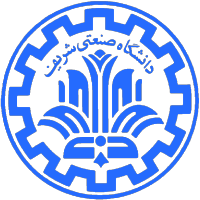

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: K-Means Clustering<br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [ ]:
student_number = '402105965'
full_name = 'Reyhane Khayatzade Mahani'

### Image Segmentation Using K-Means Clustering for Color-Based Region Extraction

### Description: 

In this project, you will implement **K-Means clustering from scratch** and use it to perform image segmentation based on color similarity. **Image segmentation** is the process of dividing an image into meaningful regions. In this assignment, segmentation is done using **color clustering**, where every pixel is grouped into one of K color clusters.

**⚠️ Notice:** You are allowed to use **only the imported libraries** and must **follow the provided function structure**.



# 📝 **Project Instructions**

1. **Load the image**  
   Load the input image and convert it into an **RGB numerical array**.

2. **Reshape image to pixels**  
   Flatten the image into a **2D array**, where each row represents one pixel (**R, G, B**).

3. **Initialize K cluster centers**  
   Randomly select **K pixels** to serve as the starting cluster centers.

4. **Assign pixels to nearest cluster**  
   Compute **distances** and assign each pixel to the **closest cluster center**.

5. **Update cluster centers**  
   Recalculate each center as the **mean color** of all pixels assigned to that cluster.

6. **K-Means algorithm**  
   Repeat **assignment** and **update steps** until **convergence** or **max iterations**.

7. **Reconstruct segmented image**  
   Replace each pixel with the **color of its assigned cluster center**.

8. **Using the Elbow Method**  
   Compute the Compute Within-Cluster Sum of Squares **WCSS** for various **K values** to help estimate an **optimal K**.

9. **Run the segmentation**  
   Apply your **full K-Means pipeline** to segment the chosen image.

10. **Display results**  
    Plot and **visualize** the original and segmented images **side-by-side**.


# 📤 **Expected Output**

- A **segmented image** produced by your **K-Means implementation**  
- A **plot showing the Elbow Method curve** (**WCSS vs. K**)  
- **Observe** how changing **K** affects segmentation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Step 1: Load the image
def load_image(path):
    img = Image.open(path).convert('RGB')
    data = np.array(img)
    return data


# Step 2: Reshape image to pixels
def preprocess_image(image_data):
    height, width, _ = image_data.shape
    pixels = image_data.reshape(height * width, 3)
    return pixels

In [3]:
# Step 3: Initialize K cluster centers
def initialize_centers(pixels, k):
    indices = np.random.choice(pixels.shape[0], k, replace=False)
    centers = pixels[indices]
    return centers


# Step 4: Assign pixels to nearest cluster
def assign_clusters(pixels, centers):
    diff = pixels[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dists = np.linalg.norm(diff, axis=2)
    labels = np.argmin(dists, axis=1)
    return labels


# Step 5: Update cluster centers
def update_centers(pixels, labels, k):
    new_centers = []
    for i in range(k):
        cluster_pixels = pixels[labels == i]
        if len(cluster_pixels) > 0:
            new_centers.append(np.mean(cluster_pixels, axis=0))
        else:
            new_centers.append(np.random.choice(pixels.flatten(), 3))
    return np.array(new_centers)


# Step 6: K-Means algorithm
def kmeans(pixels, k, max_iters=10, tol=1e-4):
    centers = initialize_centers(pixels, k)
    for _ in range(max_iters):
        labels = assign_clusters(pixels, centers)
        new_centers = update_centers(pixels, labels, k)
        if np.all(np.linalg.norm(new_centers - centers, axis=1) < tol):
            break
        centers = new_centers
    return centers, labels

In [4]:
# Step 7: Reconstruct segmented image

def recreate_image(labels, centers, image_shape):
    segmented_flat = centers[labels].astype(np.uint8)
    
    segmented = segmented_flat.reshape(image_shape)
    
    return segmented

In [5]:
# Step 8: Elbow Method

def calculate_wcss(pixels, max_k=10):
    wcss = []
    
    for k in range(1, max_k + 1):
        centers, labels = kmeans(pixels, k, max_iters=10)
        
        distances = np.linalg.norm(pixels - centers[labels], axis=1)
        wcss_value = np.sum(distances ** 2)
        wcss.append(wcss_value)
    
    return wcss


def plot_elbow(wcss):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(wcss) + 1), wcss, marker='o', linestyle='-', color='b')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, len(wcss) + 1))
    plt.show()

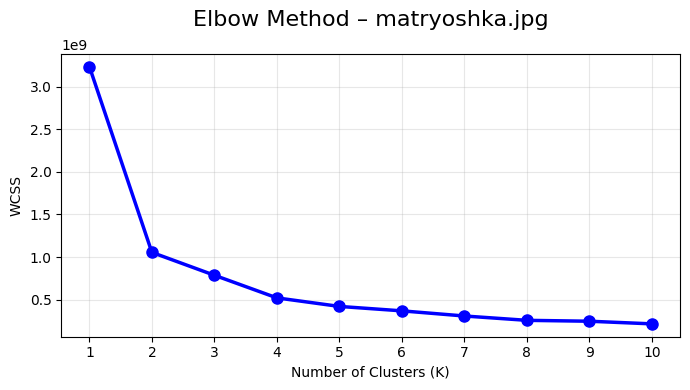

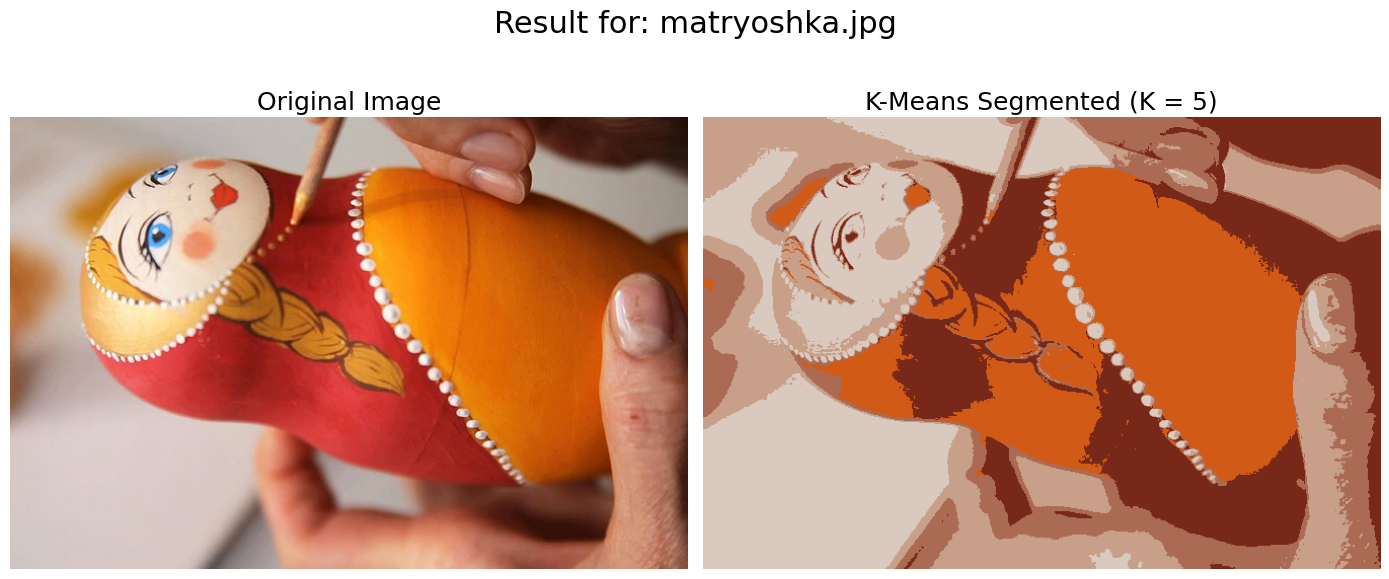

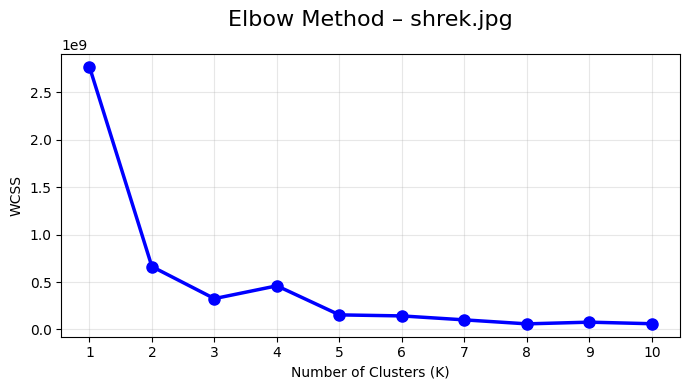

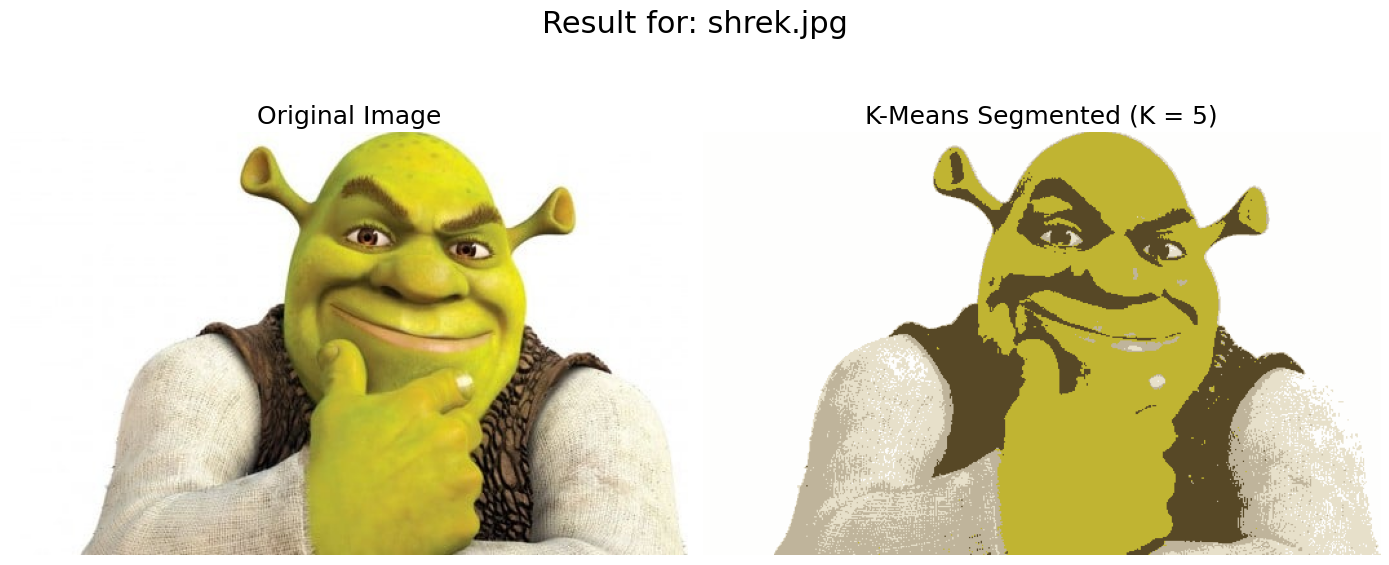

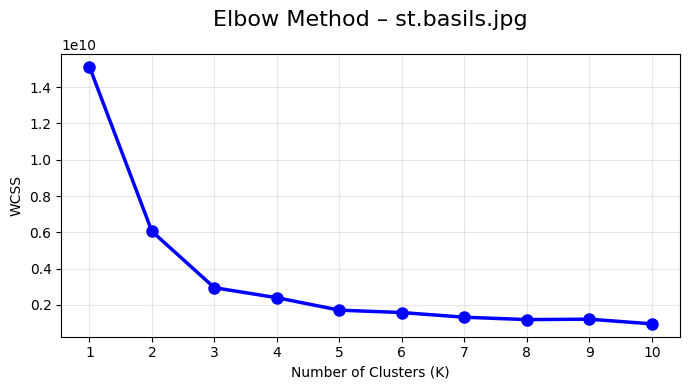

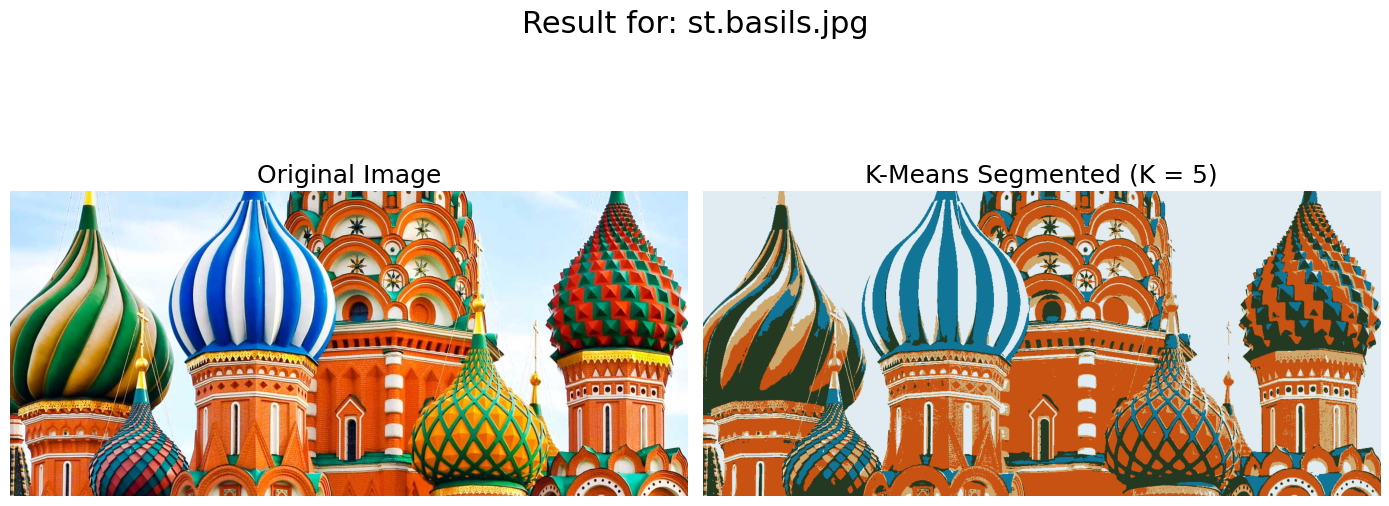

In [13]:
image_paths = ['matryoshka.jpg', 'shrek.jpg', 'st.basils.jpg']   

chosen_ks = [5, 5, 5]   

for idx, (path, K) in enumerate(zip(image_paths, chosen_ks), 1):
    original_image = load_image(path)
    pixels = preprocess_image(original_image)
    image_shape = original_image.shape
        
    wcss = calculate_wcss(pixels, max_k=10)
    
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, 11), wcss, marker='o', color='blue', linewidth=2.5, markersize=8)
    plt.title(f'Elbow Method – {path}', fontsize=16, pad=20)
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('WCSS')
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 11))
    plt.tight_layout()
    plt.show()
    
    centers, labels = kmeans(pixels, K, max_iters=30)  
    
    segmented_image = recreate_image(labels, centers, image_shape)
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original_image)
    plt.title('Original Image', fontsize=18)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(segmented_image)
    plt.title(f'K-Means Segmented (K = {K})', fontsize=18)
    plt.axis('off')
    
    plt.suptitle(f'Result for: {path}', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()